# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Fathya Intami Gusda  
**NIM:** 123450095  
**Kelas:** RB  
**Tanggal:** 2026-09-14  

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [1]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '123450095'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

Matplotlib is building the font cache; this may take a moment.


{'python': '3.11.9',
 'numpy': '2.4.6',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'torch': '2.14.0+cpu',
 'device': 'cpu',
 'seed': 1095}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter adalah nilai yang dipelajari oleh model selama proses training, seperti bobot dan bias. Sementara itu, hyperparameter adalah nilai yang ditentukan sebelum atau selama pengaturan proses training, seperti learning rate, batch size, jumlah epoch, dan hidden size.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Beberapa layer affine yang disusun tanpa fungsi aktivasi di antaranya tetap menghasilkan transformasi affine. Oleh karena itu, beberapa layer tersebut dapat digabungkan menjadi satu layer affine. Fungsi aktivasi nonlinier diperlukan agar jaringan dapat mempelajari hubungan yang lebih kompleks.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** Shape bobotnya adalah (8, 2), karena terdapat 8 neuron keluaran dan masing-masing menerima 2 masukan.
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** BCEWithLogitsLoss menerima logit karena fungsi ini sudah menggabungkan operasi sigmoid dengan binary cross-entropy secara numerik lebih stabil. Oleh karena itu, sigmoid tidak perlu diterapkan terlebih dahulu pada output model.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Saya memprediksi kombinasi aktivasi tanh dan hidden size 16 akan menghasilkan validation loss terbaik. Hal ini karena data make_moons memiliki pola nonlinier yang melengkung, sehingga model membutuhkan fungsi aktivasi nonlinier untuk membentuk decision boundary yang sesuai. Hidden size 16 juga memberikan kapasitas model yang lebih besar dibandingkan hidden size 4 untuk mempelajari pola tersebut. Selain itu, fungsi tanh memiliki keluaran pada rentang negatif hingga positif dan diharapkan dapat membantu model mempelajari hubungan nonlinier pada data.


## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [2]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    # Sigmoid yang stabil untuk nilai positif/negatif besar
    out = np.empty_like(z, dtype=float)

    positive = z >= 0
    out[positive] = 1 / (1 + np.exp(-z[positive]))

    exp_z = np.exp(z[~positive])
    out[~positive] = exp_z / (1 + exp_z)

    return out


def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0, z)


def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    return np.where(z > 0, z, alpha * z)


def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    # Validasi shape
    if X.ndim != 2:
        raise ValueError("X harus berupa array 2 dimensi")

    if w.ndim != 1:
        raise ValueError("w harus berupa array 1 dimensi")

    if X.shape[1] != w.shape[0]:
        raise ValueError("Jumlah fitur X harus sama dengan panjang w")

    # Hitung linear combination
    z = X @ w + b

    # Terapkan fungsi aktivasi
    a = activation(z)

    return z, a

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


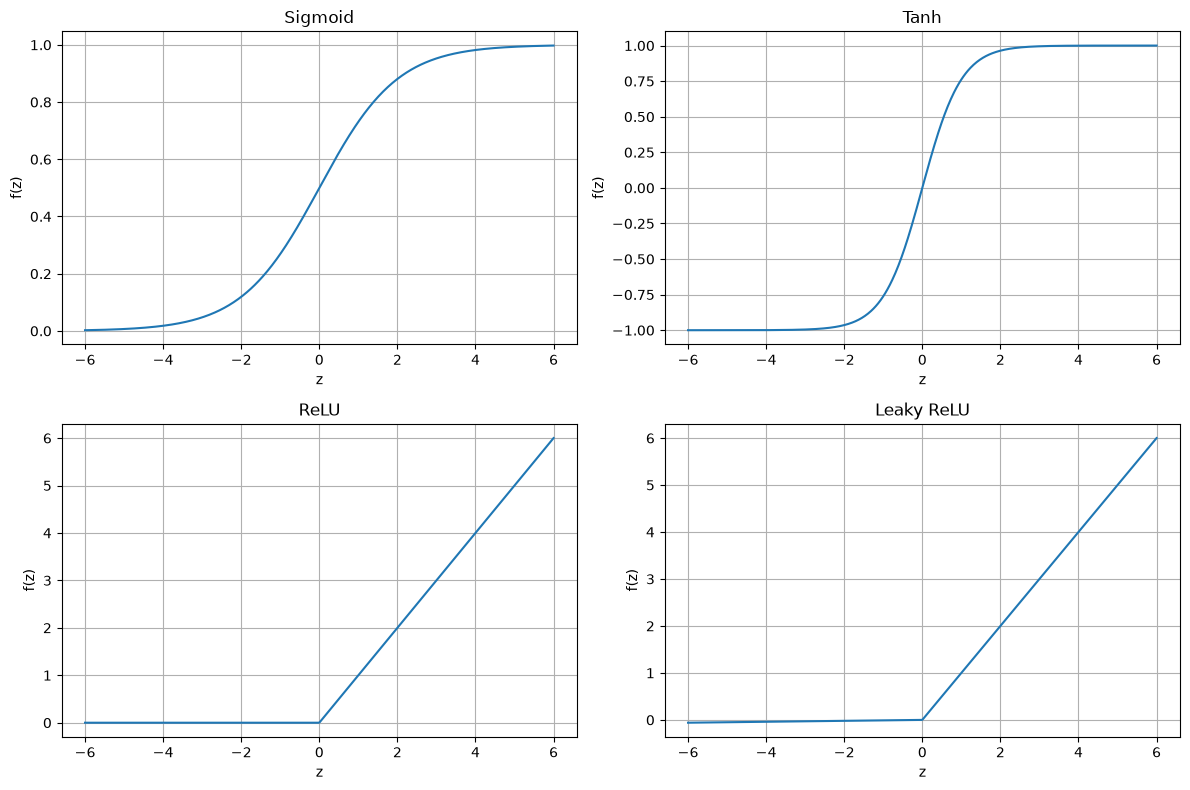

In [3]:
grid = np.linspace(-6, 6, 600)

# Lengkapi kamus dengan empat fungsi aktivasi
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

# Membuat subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values)
    ax.set_title(name)
    ax.set_xlabel("z")
    ax.set_ylabel("f(z)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: `tanh`, karena outputnya berada pada rentang -1 sampai 1 dan berpusat di sekitar nol.
- Aktivasi yang tepat nol untuk masukan negatif: `ReLU`, karena input negatif menghasilkan output 0.
- Aktivasi yang mudah jenuh: `Sigmoid` dan `tanh`, terutama pada input yang sangat besar positif atau negatif.
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: Karena pola `make_moons` bersifat nonlinier, sedangkan aktivasi linear hanya dapat membentuk hubungan linear sehingga tidak dapat membentuk *decision boundary* yang melengkung.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [7]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np = x_manual @ W1.T + b1
h_np = relu_np(z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
bce_np = -(y_manual * np.log(prob_np) + (1-y_manual) * np.log(1-prob_np)).mean()

parameter_count_manual = W1.size + b1.size + W2.size + b2.size

print("BCE:", bce_np, "| Total Parameter:", parameter_count_manual)

BCE: 0.07888972967562143 | Total Parameter: 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | `(1, 2)` | `[[ 2.0, -1.0]]` |
| $W^{(1)}$ | `(2, 2)` | tersedia pada kode |
| $z^{(1)}$ | `(1, 2)` | `[[1.5, 1.0]]` |
| $h$ | `(1, 2)` | `[[1.5, 1.0]]` |
| logit | `(1, 1)` | `[[2.5]]` |
| probabilitas | `(1, 1)` | `[[0.9241]]` |
| BCE | skalar | `0.0788` |

**Jumlah parameter dan perhitungannya:** Layer pertama memiliki 4 bobot dan 2 bias, sedangkan layer kedua memiliki 2 bobot dan 1 bias. Jadi jumlah parameter adalah
$(2 \times 2) + 2 + (2 \times 1) + 1 = 9$ parameter.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [9]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# Salin bobot dan bias manual ke PyTorch
with torch.no_grad():
    manual_model[0].weight.copy_(torch.tensor(W1))
    manual_model[0].bias.copy_(torch.tensor(b1))
    manual_model[2].weight.copy_(torch.tensor(W2))
    manual_model[2].bias.copy_(torch.tensor(b2))

# Ubah input dan target ke tensor PyTorch
x_torch = torch.tensor(x_manual)
y_torch = torch.tensor(y_manual)

# Hitung logit
torch_logit = manual_model(x_torch)

# Hitung probabilitas
torch_probability = torch.sigmoid(torch_logit)

# Hitung BCE
loss_fn = nn.BCEWithLogitsLoss()
torch_loss = loss_fn(torch_logit, y_torch)

print("Torch logit:", torch_logit)
print("Torch probability:", torch_probability)
print("Torch loss:", torch_loss)

Torch logit: tensor([[2.5000]], grad_fn=<AddmmBackward0>)
Torch probability: tensor([[0.9241]], grad_fn=<SigmoidBackward0>)
Torch loss: tensor(0.0789, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** selesai

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


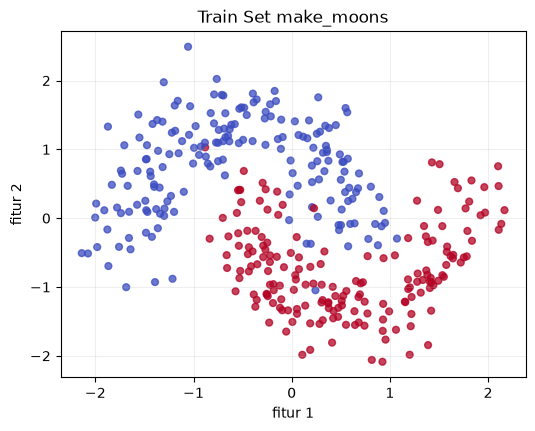

In [10]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** : Scaler hanya di-fit pada train set agar informasi dari data validasi tidak ikut digunakan dalam proses standardisasi. Jika scaler di-fit menggunakan seluruh data, informasi statistik dari data validasi dapat masuk ke proses pelatihan sehingga terjadi data leakage. Akibatnya, hasil evaluasi pada validation set dapat menjadi kurang merepresentasikan kemampuan model pada data yang belum pernah dilihat. Setelah scaler di-fit pada train set, scaler yang sama kemudian digunakan untuk melakukan transformasi pada train dan validation set.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [11]:
def activation_layer(name: str) -> nn.Module:
    # Mengembalikan fungsi aktivasi sesuai nama
    if name.lower() == 'relu':
        return nn.ReLU()
    elif name.lower() == 'tanh':
        return nn.Tanh()
    elif name.lower() == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Aktivasi tidak dikenali: {name}")


def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)

    # Arsitektur: 2 -> hidden_dim -> 1
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1)
    )

    return model


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


# Buat model 2 -> 8 -> 1
model_check = build_model(8, 'relu')

# Periksa jumlah parameter
assert count_parameters(model_check) == 33

print("Jumlah parameter:", count_parameters(model_check))

Jumlah parameter: 33


In [13]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Saya memprediksi aktivasi sigmoid akan menghasilkan validation loss yang cukup baik karena memberikan transformasi nonlinier untuk klasifikasi biner. Namun, sigmoid berpotensi mengalami saturasi sehingga proses pembelajaran dapat berlangsung lebih lambat.

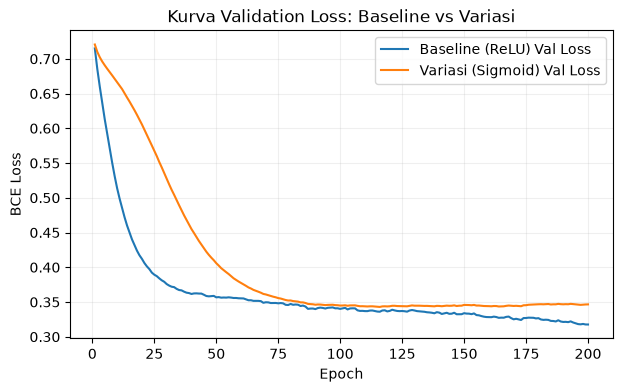

,activation,hidden_dim,parameters,val_loss,val_accuracy,runtime_seconds
0,relu,8,33,0.3176,0.875,7.0095
1,sigmoid,8,33,0.3466,0.850,6.9800


In [16]:
# Latih baseline (ReLU, hidden_dim=8)
baseline_model = build_model(
    hidden_dim=8,
    activation='relu',
    seed=SEED
)

baseline_history, baseline_runtime = train_model(
    baseline_model,
    seed=SEED
)

baseline_val = evaluate(
    baseline_model,
    X_val_t,
    y_val_t
)


# Latih variasi individual (Sigmoid, hidden_dim=8)
# NIM berakhiran 5 -> menggunakan Sigmoid
variant_name = 'sigmoid'

variant_model = build_model(
    hidden_dim=8,
    activation=variant_name,
    seed=SEED
)

variant_history, variant_runtime = train_model(
    variant_model,
    seed=SEED
)

variant_val = evaluate(
    variant_model,
    X_val_t,
    y_val_t
)


# Menampilkan grafik perbandingan validation loss
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    baseline_history['epoch'],
    baseline_history['val_loss'],
    label='Baseline (ReLU) Val Loss'
)

ax.plot(
    variant_history['epoch'],
    variant_history['val_loss'],
    label='Variasi (Sigmoid) Val Loss'
)

ax.set(
    title='Kurva Validation Loss: Baseline vs Variasi',
    xlabel='Epoch',
    ylabel='BCE Loss'
)

ax.legend()
ax.grid(alpha=0.2)

plt.show()


# Tabel hasil
pd.DataFrame([
    {
        'activation': 'relu',
        'hidden_dim': 8,
        'parameters': count_parameters(baseline_model),
        'val_loss': baseline_val['loss'],
        'val_accuracy': baseline_val['accuracy'],
        'runtime_seconds': baseline_runtime
    },
    {
        'activation': variant_name,
        'hidden_dim': 8,
        'parameters': count_parameters(variant_model),
        'val_loss': variant_val['loss'],
        'val_accuracy': variant_val['accuracy'],
        'runtime_seconds': variant_runtime
    }
]).sort_values('val_loss')

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [18]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

for activation in ACTIVATIONS:
    for hidden_dim in HIDDEN_SIZES:

        # 1. Buat model baru dengan seed yang sama
        model = build_model(
            hidden_dim=hidden_dim,
            activation=activation,
            seed=SEED
        )

        # 2. Latih model dengan pengaturan yang sama
        history, runtime = train_model(
            model,
            seed=SEED
        )

        # 3. Evaluasi pada train dan validation
        train_metrics = evaluate(
            model,
            X_train_t,
            y_train_t
        )

        val_metrics = evaluate(
            model,
            X_val_t,
            y_val_t
        )

        # 4. Simpan model dan history
        key = f"{activation}_{hidden_dim}"

        trained_models[key] = model
        histories[key] = history

        # 5. Simpan metrik eksperimen
        experiment_rows.append({
            'activation': activation,
            'hidden_dim': hidden_dim,
            'parameters': count_parameters(model),
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'runtime_seconds': runtime
        })


# Buat tabel hasil
results = pd.DataFrame(experiment_rows).sort_values(
    'val_loss'
).reset_index(drop=True)

assert len(results) == 6

display(results)

# Simpan hasil ke CSV
results.to_csv(
    f'M01_{NIM_LAST4:04d}_metrics.csv',
    index=False
)
#raise NotImplementedError('Jalankan enam eksperimen dan simpan metrics.csv.')

,activation,hidden_dim,parameters,train_loss,train_accuracy,val_loss,val_accuracy,runtime_seconds
0,relu,16,65,0.1761,0.9167,0.2505,0.9000,6.6912
1,tanh,16,65,0.1927,0.9028,0.2579,0.9000,6.7222
2,tanh,4,17,0.2592,0.8889,0.3258,0.8667,6.7125
3,relu,4,17,0.2410,0.8889,0.3326,0.8583,6.9659
4,sigmoid,16,65,0.2716,0.8750,0.3443,0.8500,6.6723
5,sigmoid,4,17,0.2772,0.8750,0.3490,0.8417,6.9785


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model Terbaik (relu_16) - TEST LOSS: 0.2642 | TEST ACCURACY: 0.8583


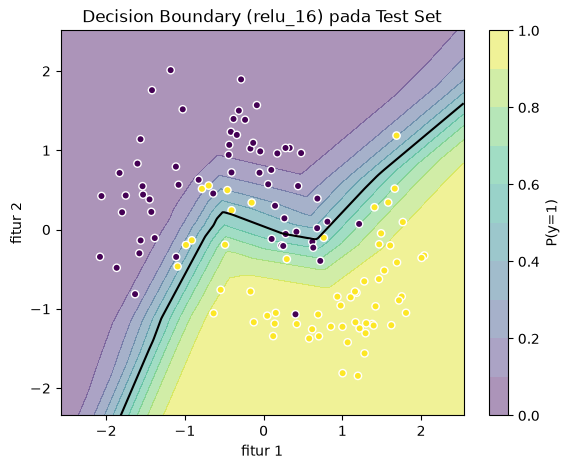

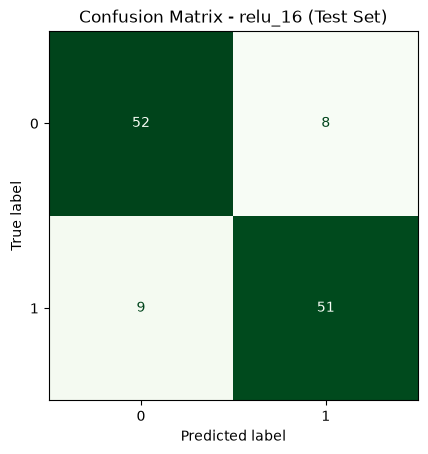

In [22]:
def plot_decision_boundary(model, X_values, y_values, title):
    x0_min, x0_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    x1_min, x1_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, 220),
        np.linspace(x1_min, x1_max, 220),
    )

    mesh = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32,
        device=DEVICE
    )

    model.eval()

    with torch.no_grad():
        probabilities = torch.sigmoid(model(mesh)).cpu().numpy().reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5))

    contour = ax.contourf(
        xx, yy, probabilities,
        levels=np.linspace(0, 1, 11),
        cmap='viridis',
        alpha=0.45
    )

    ax.contour(
        xx,
        yy,
        probabilities,
        levels=[0.5],
        colors='black',
        linewidths=1.5
    )

    ax.scatter(
        X_values[:, 0],
        X_values[:, 1],
        c=y_values,
        cmap='viridis',
        edgecolor='white',
        s=28
    )

    ax.set(
        title=title,
        xlabel='fitur 1',
        ylabel='fitur 2'
    )

    fig.colorbar(contour, ax=ax, label='P(y=1)')
    plt.show()


# Memanggil hasil terbaik dari validation set
best_config = results.iloc[0]

best_model_name = (
    f"{best_config['activation']}_{best_config['hidden_dim']}"
)

best_model = trained_models[best_model_name]


# Evaluasi TEST SET satu kali
test_metrics = evaluate(
    best_model,
    X_test_t,
    y_test_t
)

print(
    f"Model Terbaik ({best_model_name}) - "
    f"TEST LOSS: {test_metrics['loss']:.4f} | "
    f"TEST ACCURACY: {test_metrics['accuracy']:.4f}"
)


# Decision Boundary pada Test Set
plot_decision_boundary(
    best_model,
    X_test_s,
    y_test,
    f'Decision Boundary ({best_model_name}) pada Test Set'
)


# Confusion Matrix
cm = confusion_matrix(
    y_test,
    test_metrics['predictions']
)

ConfusionMatrixDisplay(cm).plot(
    cmap='Greens',
    colorbar=False
)

plt.title(
    f'Confusion Matrix - {best_model_name} (Test Set)'
)

plt.show()

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? **Tidak selalu. Penambahan hidden size dari 4 menjadi 16 tidak otomatis menghasilkan validation loss yang lebih rendah pada setiap fungsi aktivasi. Hal ini menunjukkan bahwa kapasitas model yang lebih besar belum tentu memberikan performa validasi yang lebih baik.**
2. Aktivasi mana yang paling stabil pada dua hidden size? **Aktivasi yang paling stabil adalah aktivasi yang memiliki perubahan validation loss paling kecil ketika hidden size berubah dari 4 menjadi 16. Penentuannya perlu dilihat dari nilai validation loss keenam konfigurasi pada tabel hasil eksperimen.**
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? **Ya. Accuracy yang serupa tidak selalu menghasilkan nilai BCE yang sama. Accuracy hanya menghitung benar atau salahnya klasifikasi berdasarkan batas probabilitas 0,5, sedangkan BCE juga mempertimbangkan tingkat keyakinan model terhadap prediksinya. Oleh karena itu, dua konfigurasi dapat memiliki accuracy yang hampir sama tetapi BCE yang berbeda.**
4. Di bagian mana decision boundary paling tidak pasti? **Berdasarkan grafik decision boundary relu_16, bagian yang paling tidak pasti berada di sekitar garis hitam dengan probabilitas mendekati 0,5, terutama pada area pertemuan kedua kelompok data di bagian tengah pola make_moons. Pada daerah tersebut model lebih sulit menentukan kelas karena probabilitas prediksinya berada di antara kedua kelas. Hal ini juga terlihat dari adanya 8 data kelas 0 yang diprediksi sebagai kelas 1 dan 9 data kelas 1 yang diprediksi sebagai kelas 0 pada confusion matrix**
5. Apa satu keterbatasan eksperimen ini? **Salah satu keterbatasan eksperimen adalah konfigurasi yang diuji masih terbatas, yaitu hanya tiga jenis aktivasi (ReLU, Tanh, dan Sigmoid) serta dua hidden size (4 dan 16). Dengan demikian, hasil eksperimen belum menunjukkan bahwa konfigurasi yang dipilih merupakan konfigurasi optimal untuk semua kemungkinan hyperparameter.**
6. Apakah hasil sesuai hipotesis awal? **Hasil tidak sesuai dengan hipotesis awal. Sebelumnya diprediksi bahwa kombinasi Tanh dengan hidden size 16 akan menghasilkan validation loss terbaik. Namun, berdasarkan hasil enam eksperimen, model terbaik adalah ReLU dengan hidden size 16 (relu_16). Pada test set, model tersebut memperoleh test loss 0,2642 dan accuracy 0,8583 atau 85,83%.**

## Checklist pengumpulan - 5 poin reproduksibilitas

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [ ] Enam eksperimen tercatat pada notebook dan CSV.
- [ ] Test set hanya dipakai untuk model final.
- [ ] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [ ] Notebook lolos Restart Kernel and Run All.
- [ ] Tidak ada path absolut atau data pribadi.
- [ ] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Fathya Intami Gusda, 14/09/2026